# MLP classification

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch 
from torch.utils.data import DataLoader, Dataset
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

## 2. Load dataset

In [ ]:
data_path = '../data/NonLinear_data.npy'
data = np.load(data_path, allow_pickle=True).item()  # load dữ liệu
X,labels = data['X'],data['labels'] 
X = torch.tensor(X,dtype=torch.float32)     # Chuyển dữ liệu thành tensor
labels = torch.tensor(labels,dtype=torch.long) # Chuyển nhãn thành tensor

In [ ]:
class CustomDataset(Dataset):       
    def __init__(self,x,y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)      # Trả về số lượng mẫu 
    def __getitem__(self,idx):  # Trả về một mẫu
        return self.x[idx],self.y[idx]  # Trả về một mẫu

train_data = CustomDataset(X, labels)       # Tạo dataset
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)      # Tạo loader

In [12]:
class softmaxregression(nn.Module):
    def __init__(self, input_dims, num_classes):
        super(softmaxregression,self).__init__()        # Gọi constructor của lớp cha
        self.linear = nn.Linear(input_dims,num_classes)     # Tạo layer linear
    def forward(self,x):
        return self.linear(x)

model = softmaxregression(input_dims=2,num_classes=3).to(device)    # Khởi tạo model
criterion = nn.CrossEntropyLoss()     # Tạo loss function
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)     # Tạo optimizer
        

In [18]:
num_epochs = 200
train_losses = []
train_acc = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    accuracy = 0
    cnt = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        accuracy += (torch.argmax(outputs, 1) == y).sum().item()
        cnt += len(y)
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    accuracy /= cnt
    train_acc.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train_Loss: {train_loss:.4f},  Train_Acc: {accuracy:.4f}")

Epoch 1/200, Train_Loss: 0.9602,  Train_Acc: 0.5767
Epoch 2/200, Train_Loss: 0.9503,  Train_Acc: 0.5567
Epoch 3/200, Train_Loss: 0.9372,  Train_Acc: 0.5367
Epoch 4/200, Train_Loss: 0.9174,  Train_Acc: 0.5367
Epoch 5/200, Train_Loss: 0.9072,  Train_Acc: 0.5233
Epoch 6/200, Train_Loss: 0.8941,  Train_Acc: 0.5333
Epoch 7/200, Train_Loss: 0.8858,  Train_Acc: 0.5300
Epoch 8/200, Train_Loss: 0.8696,  Train_Acc: 0.5267
Epoch 9/200, Train_Loss: 0.8734,  Train_Acc: 0.5233
Epoch 10/200, Train_Loss: 0.8607,  Train_Acc: 0.5300
Epoch 11/200, Train_Loss: 0.8531,  Train_Acc: 0.5300
Epoch 12/200, Train_Loss: 0.8370,  Train_Acc: 0.5367
Epoch 13/200, Train_Loss: 0.8475,  Train_Acc: 0.5267
Epoch 14/200, Train_Loss: 0.8384,  Train_Acc: 0.5300
Epoch 15/200, Train_Loss: 0.8339,  Train_Acc: 0.5233
Epoch 16/200, Train_Loss: 0.8329,  Train_Acc: 0.5267
Epoch 17/200, Train_Loss: 0.8138,  Train_Acc: 0.5233
Epoch 18/200, Train_Loss: 0.8153,  Train_Acc: 0.5233
Epoch 19/200, Train_Loss: 0.8238,  Train_Acc: 0.5200
Ep

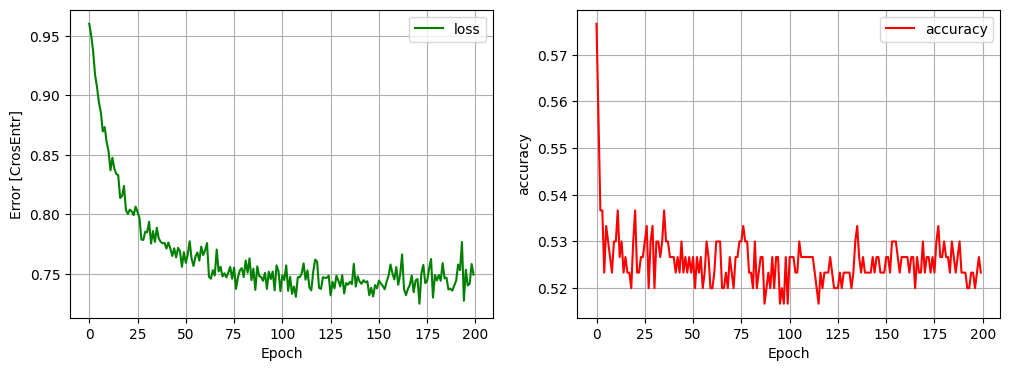

In [20]:
fig = plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Error [CrosEntr]')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='accuracy', color='red')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

